In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine, text
from dotenv import load_dotenv
import os

In [6]:
# Задаем константы
ENV_PATH = r"C:\Users\D\Python scripts\Innopolis 2026\AI architecht\.env"
SQL_PATH = r"C:\Users\D\Python scripts\Innopolis 2026\AI architecht\SQL\attest_1.sql"
WORKING_PATH = r"C:\Courses\Innopolis\2026\ИИ Инженер\Консультации"

# 1. Забираем SQL скрипт и грузим в dataframe

In [22]:
def read_sql_script(sql_path):
    # Контекстный менеджер
    with open(sql_path, 'r', encoding='utf-8') as file:
        sql_script = file.read()
    return sql_script

def create_connection_url(env_path):
    # Загружаем .env
    load_dotenv(env_path)

    # Забираем креды
    host = os.getenv("DB_HOST")
    port = os.getenv("DB_PORT")
    database = os.getenv("DB_NAME")
    user = os.getenv("DB_USER")
    password = os.getenv("DB_PASSWORD")

    # Создаем url для подключения
    return f"postgresql://{user}:{password}@{host}:{port}/{database}"

def load_sql_data(engine, sql_script):
    return pd.read_sql(text(sql_script),engine)

def load_sql_to_pandas(sql_path, env_path):
    sql_script = read_sql_script(sql_path)
    conn_url = create_connection_url(env_path)
    engine = create_engine(conn_url)
    df = load_sql_data(engine, sql_script)
    return df

In [13]:
# Проверим, что загрузилось
print(read_sql_script(SQL_PATH))

WITH overdue_rentals AS (
	SELECT 
		rental.rental_id,
		rental.inventory_id,
		rental.customer_id,
		rental.staff_id,
		film.film_id,
		film.rental_rate,
		film.length, 
		film.replacement_cost,
		film.rating, 
		category.name AS film_category,
		EXTRACT (EPOCH FROM rental.return_date - rental.rental_date)::FLOAT/86400 AS fact_rental,
		film.rental_duration AS normative_rental,
		CASE WHEN EXTRACT (EPOCH FROM rental.return_date - rental.rental_date)::FLOAT/86400 > film.rental_duration THEN 1 ELSE 0 END AS is_overdue
	FROM rental
	LEFT JOIN inventory 
	ON rental.inventory_id = inventory.inventory_id
	LEFT JOIN film 
	ON inventory.film_id = film.film_id
	LEFT JOIN film_category 
	ON film.film_id = film_category.film_id
	LEFT JOIN category
	ON film_category.category_id = category.category_id
	WHERE return_date IS NOT NULL
)
SELECT *
FROM overdue_rentals

-- , cust_agg AS (
-- 	SELECT 
-- 		customer_id,
-- 		COUNT(rental_id) AS cnt_rental,
-- 		AVG(is_overdue) AS overdue_pct
-- 	FROM over

In [23]:
df = load_sql_to_pandas(SQL_PATH, ENV_PATH)

In [24]:
df.head()

,rental_id,inventory_id,customer_id,staff_id,film_id,rental_rate,length,replacement_cost,rating,film_category,fact_rental,normative_rental,is_overdue
0,2,1525,459,1,333,2.99,126,16.99,R,Music,3.865278,7,0
1,3,1711,408,1,373,2.99,156,14.99,G,Children,7.964583,7,1
2,4,2452,333,2,535,0.99,181,21.99,R,Horror,9.110417,6,1
3,5,2079,222,1,450,2.99,84,29.99,NC-17,Children,8.227778,5,1
4,6,2792,549,1,613,0.99,92,19.99,NC-17,Comedy,2.100000,5,0


# 2. Строим агрегаты из полученной таблицы

In [28]:
def make_aggregate_df(df, grouping_column):
    agg_df = (
        df
        .groupby(grouping_column)
        .agg(
            cnt_rental = ("rental_id", "count"),
            overdue_pct = ("is_overdue", "mean"),
        )
        .sort_values(by = "overdue_pct", ascending = False)
    )
    return agg_df

### Cмотрим количество прокатов и процент просрочки по клиентам

In [30]:
cust_df = make_aggregate_df(df, grouping_column = "customer_id")
cust_df

,cnt_rental,overdue_pct
customer_id,,
321,22,0.863636
427,24,0.833333
542,18,0.777778
295,37,0.756757
464,16,0.750000
...,...,...
378,19,0.263158
586,19,0.263158
549,20,0.250000


### Cмотрим количество прокатов и процент просрочки по фильмам

In [31]:
film_df = make_aggregate_df(df, grouping_column = "film_id")
film_df

,cnt_rental,overdue_pct
film_id,,
750,10,1.000000
704,15,0.933333
654,15,0.933333
652,14,0.928571
879,27,0.925926
...,...,...
362,5,0.000000
885,6,0.000000
188,9,0.000000


### Cмотрим количество прокатов и процент просрочки по категориям фильмов

In [32]:
film_cat_df = make_aggregate_df(df, grouping_column = "film_category")
film_cat_df

,cnt_rental,overdue_pct
film_category,,
Sports,1164,0.556701
Comedy,932,0.549356
New,927,0.549083
Documentary,1043,0.547459
Games,955,0.536126
Sci-Fi,1093,0.533394
Horror,834,0.525180
Action,1095,0.505936
Family,1083,0.501385


### Cмотрим количество прокатов и процент просрочки по работникам

In [55]:
make_aggregate_df(df, grouping_column = "staff_id")

,cnt_rental,overdue_pct
staff_id,,
2,7906,0.515937
1,7955,0.508108


# 3. Разведочный анализ данных

## Смотрим на общие характеристики датафрейма

In [38]:
df.head()

,rental_id,inventory_id,customer_id,staff_id,film_id,rental_rate,length,replacement_cost,rating,film_category,fact_rental,normative_rental,is_overdue
0,2,1525,459,1,333,2.99,126,16.99,R,Music,3.865278,7,0
1,3,1711,408,1,373,2.99,156,14.99,G,Children,7.964583,7,1
2,4,2452,333,2,535,0.99,181,21.99,R,Horror,9.110417,6,1
3,5,2079,222,1,450,2.99,84,29.99,NC-17,Children,8.227778,5,1
4,6,2792,549,1,613,0.99,92,19.99,NC-17,Comedy,2.100000,5,0


In [34]:
# Количество записей об арендах в датафрейме
df.shape

(15861, 13)

In [39]:
# Типы данных в датафрейме + пропуски
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15861 entries, 0 to 15860
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   rental_id         15861 non-null  int64  
 1   inventory_id      15861 non-null  int64  
 2   customer_id       15861 non-null  int64  
 3   staff_id          15861 non-null  int64  
 4   film_id           15861 non-null  int64  
 5   rental_rate       15861 non-null  float64
 6   length            15861 non-null  int64  
 7   replacement_cost  15861 non-null  float64
 8   rating            15861 non-null  object 
 9   film_category     15861 non-null  object 
 10  fact_rental       15861 non-null  float64
 11  normative_rental  15861 non-null  int64  
 12  is_overdue        15861 non-null  int64  
dtypes: float64(3), int64(8), object(2)
memory usage: 1.6+ MB


Поскольку fact_rental и normative_rental по природе являются похожими, лучше normative_rental перевести в тип float

In [40]:
df["normative_rental"] = df["normative_rental"].astype(float)

## Распределение целевой переменной

In [47]:
df["is_overdue"].value_counts().sort_index()

is_overdue
0    7740
1    8121
Name: count, dtype: int64

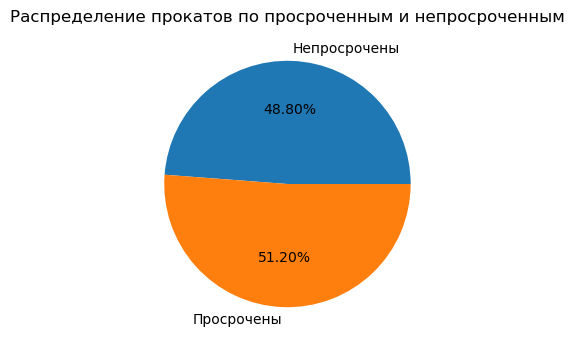

In [54]:
fig, ax = plt.subplots(1, 1, figsize = (8,4))
ax.pie(
    df["is_overdue"].value_counts().sort_index().values,
    labels = ["Непросрочены", "Просрочены"],
    autopct = '%0.2f%%'
)
ax.set_title("Распределение прокатов по просроченным и непросроченным")
plt.show()

По долям просроченных и непросроченных прокатов видно, что выборка сбалансирована

## Распределение потенциальных предикторов

Кандидатами на атрибуты для модели классификации будут:
- customer_id
- staff_id
- film_id
- rental_rate
- length
- replacement_cost
- rating
- film_category
- normative_rental

### Берем replacement cost (числовой атрибут)

In [58]:
df["replacement_cost"].describe()

count    15861.000000
mean        20.224727
std          6.083784
min          9.990000
25%         14.990000
50%         20.990000
75%         25.990000
max         29.990000
Name: replacement_cost, dtype: float64

- Переменная replacement cost симметрично распределена (mean и median (50%) примерно равны)
- Очевидных выбросов нет (min и max находятся недалеко от mean)

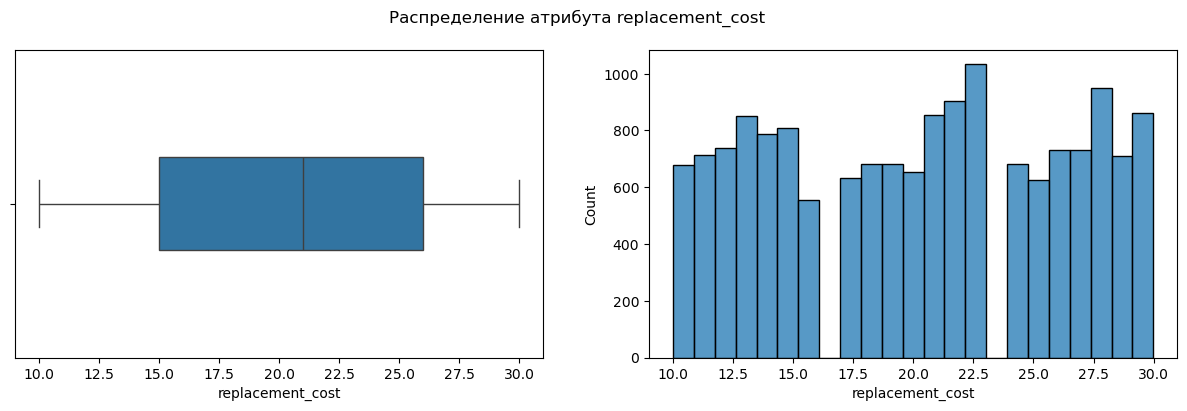

In [62]:
fig, ax = plt.subplots(1, 2, figsize = (15,4))
sns.boxplot(x = "replacement_cost", data = df, width = 0.3, ax = ax[0])
sns.histplot(x = "replacement_cost", data = df, ax = ax[1])
plt.suptitle("Распределение атрибута replacement_cost")
plt.show()

### Берем film_category (категориальный атрибут)

In [63]:
df["film_category"].describe()

count      15861
unique        16
top       Sports
freq        1164
Name: film_category, dtype: object

In [65]:
df["film_category"].value_counts().reset_index()

,film_category,count
0,Sports,1164
1,Animation,1145
2,Action,1095
3,Sci-Fi,1093
4,Family,1083
5,Drama,1053
6,Documentary,1043
7,Foreign,1022
8,Games,955
9,Children,939


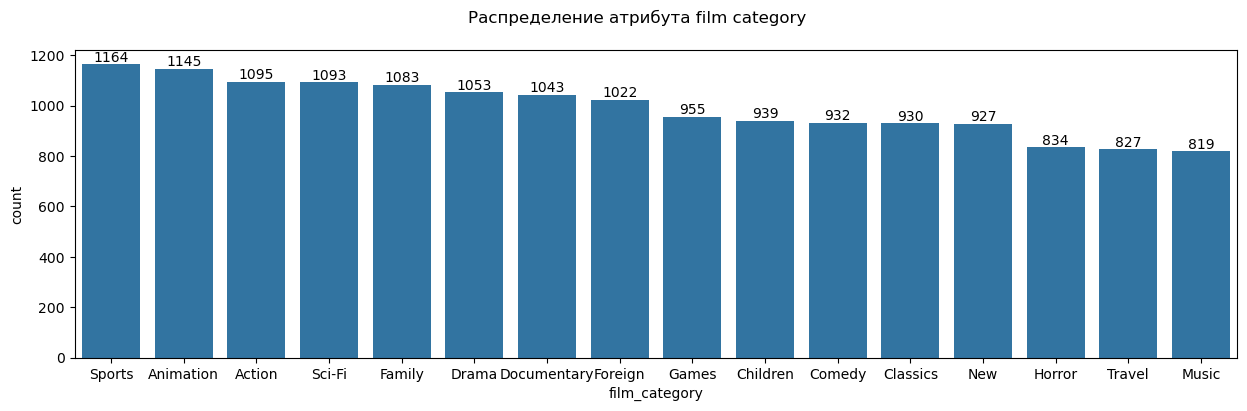

In [70]:
fig, ax = plt.subplots(1, 1, figsize = (15,4))
sns.barplot(x = "film_category", y = "count", data = df["film_category"].value_counts().reset_index(), ax = ax)
for container in ax.containers:
    ax.bar_label(container)
plt.suptitle("Распределение атрибута film category")
plt.show()

Среди категорий фильмов нет тех, которые бы существенно отличались от остальных в большую или меньшую сторону

Каких-то аномалий не обнаружено